In [1]:
# IMPORT I URUCHOMIENIE MODELU Z PLIKÓW .PY

import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from app import zaladuj_i_wytrenuj_system

# Konfiguracja wykresów
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

ranker, slownik_slow = zaladuj_i_wytrenuj_system()

print("Model z plików .py został zaimportowany")

2026-05-28 14:04:02.924 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-28 14:04:02.926 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-05-28 14:04:02.927 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:04:10.262 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:04:10.280 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-28 14:04:11.413 
  command:

    streamlit run C:\Users\jowit\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311

Model z plików .py został zaimportowany


In [2]:
# PRZYGOTOWANIE DANYCH TESTOWYCH (RZECZYWISTE VS SYNTETYCZNE)

# Tworzymy reprezentatywną bazę autentycznych błędów 
from app import zaladuj_i_wytrenuj_system
_, czyste_slowa = zaladuj_i_wytrenuj_system()

# Baza autentycznych błędów 
lista_bledow = [
    ("mlieko", "mleko"),
    ("krzeslem", "krześle"),
    ("faraun", "faraon"),
    ("samochut", "samochód"),
    ("ksiaze", "książę"), 
    ("przedwiosne", "przedwiośnie"),
    ("kote", "kot"),
    ("obedzie", "obiedzie"),
    ("ksiazka", "książka"),
    ("swiat", "świat"),
    ("ruza", "róża"),
    ("dzien dzisiejszy", "dzisiaj"),
    ("na prawde", "naprawdę"),
    ("wogóle", "w ogóle"),
    ("na codzień", "na co dzień"),
    ("po za tym", "poza tym"),
    ("niewiem", "nie wiem"),
    ("conajmniej", "co najmniej"),
    ("wziąść", "wziąć"),
    ("na przeciwko", "naprzeciwko"),
    ("złodzieji", "złodziei"),
    ("z przed", "sprzed"),
    ("dlatego bo", "dlatego że"),
    ("jusz", "już"),
    ("trwać nadal", "trwać"),
    ("okres czasu", "okres"),
    ("kartka papieru", "kartka"),
    ("w każdym bądź razie", "w każdym razie"),
    ("spadać w dół", "spadać"),
    ("fakt autentyczny", "fakt"),
    ("po najmniejszej linii oporu", "po linii najmniejszego oporu"),
    ("akwen wodny", "akwen"),
    ("języczek uwagi", "języczek u wagi"),
    ("ludzią", "ludziom"),
    ("doktur", "doktor"),
    ("dziecią", "dzieciom"),
    ("kupywać", "kupować"),
    ("derektor", "dyrektor"),
    ("lubiałem", "lubiłem"),
    ("pierwszy", "pierwsza"),
    ("poszłem", "poszedłem"),
    ("ktury", "który"),
    ("morze", "może"),
    ("napisalem", "napisałem"),
    ("włanczać", "włączać"),
    ("wyłanczać", "wyłączać"),
    ("prubować", "próbować"),
    ("tagże", "także"),
    ("tesz", "też"),
    ("wsumie", "w sumie"),
    ("odrazu", "od razu"),
    ("spowrotem", "z powrotem"),
    ("nie potrzebny", "niepotrzebny"),
    ("zaden", "żaden"),
    ("zadko", "rzadko"),
    ("rzycie", "życie"),
    ("higjena", "higiena"),
    ("chałas", "hałas"),
    ("niemoge", "nie mogę"),
    ("nieumiem", "nie umiem"),
    ("jak by", "jakby"),
    ("poraz", "po raz"),
    ("w tedy", "wtedy"),
    ("cofać do tyłu", "cofać"),
    ("akapit tekstu", "akapit")
]

# Generator błędów syntetycznych (losowa podmiana, usunięcie lub wstawienie litery)
def generate_synthetic_error(word):
    if len(word) <= 2:
        return word
    chars = "abcdefghijklmnopqrstuvwxyząćęłńóśźż"
    idx = random.randint(0, len(word) - 1)
    error_type = random.choice(["sub", "del", "ins"])
    
    if error_type == "sub": # Podmiana litery
        return word[:idx] + random.choice(chars) + word[idx+1:]
    elif error_type == "del": # Usunięcie litery
        return word[:idx] + word[idx+1:]
    else: # Wstawienie litery
        return word[:idx] + random.choice(chars) + word[idx:]

# Zbiór błędów syntetycznych
synthetic_data = []
slowa_do_zepsucia = random.sample(list(czyste_slowa), min(100, len(czyste_slowa)))

for slowo in slowa_do_zepsucia:
    bledne = generate_synthetic_error(slowo)
    if bledne != slowo:
        synthetic_data.append((bledne, slowo)) 

print(f"Przygotowano {len(lista_bledow)} błędów rzeczywistych.")
print(f"Wygenerowano {len(synthetic_data)} błędów sztucznych (syntetycznych).")

Przygotowano 65 błędów rzeczywistych.
Wygenerowano 99 błędów sztucznych (syntetycznych).


In [3]:
#  ANALIZA METRYK (ACCURACY@K, MRR)

def evaluate_corpus(dataset, name="Zbiór danych"):
    correct_at_1 = 0
    correct_at_3 = 0
    correct_at_5 = 0
    mrr_sum = 0
    total = len(dataset)
    
    # Rozpakowujemy dokładnie 2 wartości (błąd i poprawna forma)
    for err_w, corr_w in dataset:
        
        # Symulujemy stały kontekst (token początku zdania) dla rankera bigramowego
        prev_w = "<s>" 
        
        # Odpytanie drzewa BK
        candidates = ranker.bk_tree.search(err_w, max_dist=2)
        
        # Scoring kanału szumowego
        scored = []
        for cand, _ in candidates:
            score = ranker.score_candidate(prev_w, cand, err_w, k=0.1)
            scored.append((cand, score))
            
        # Sortowanie od najwyższego wyniku (prawdopodobieństwa)
        scored = [c for c, _ in sorted(scored, key=lambda x: x[1], reverse=True)]
        
        # Wyliczanie Accuracy@k
        if corr_w in scored[:1]: correct_at_1 += 1
        if corr_w in scored[:3]: correct_at_3 += 1
        if corr_w in scored[:5]: correct_at_5 += 1
        
        # Wyliczanie Mean Reciprocal Rank (MRR)
        if corr_w in scored:
            rank = scored.index(corr_w) + 1
            mrr_sum += 1.0 / rank
            
    metrics = {
        "Accuracy@1": correct_at_1 / total,
        "Accuracy@3": correct_at_3 / total,
        "Accuracy@5": correct_at_5 / total,
        "MRR": mrr_sum / total
    }
    
    return metrics

# Uruchomienie kalkulatora dla obu oczyszczonych zbiorów
wyniki_poleval = evaluate_corpus(lista_bledow, "PolEval (Rzeczywiste)")
wyniki_synthetic = evaluate_corpus(synthetic_data, "Syntetyczne")

# Prezentacja danych
df_wyniki = pd.DataFrame([wyniki_poleval, wyniki_synthetic], index=["Błędy Rzeczywiste", "Błędy Syntetyczne"])
display(df_wyniki.round(4))

,Accuracy@1,Accuracy@3,Accuracy@5,MRR
Błędy Rzeczywiste,0.3231,0.4154,0.4462,0.3811
Błędy Syntetyczne,0.9091,0.9899,0.9899,0.9509


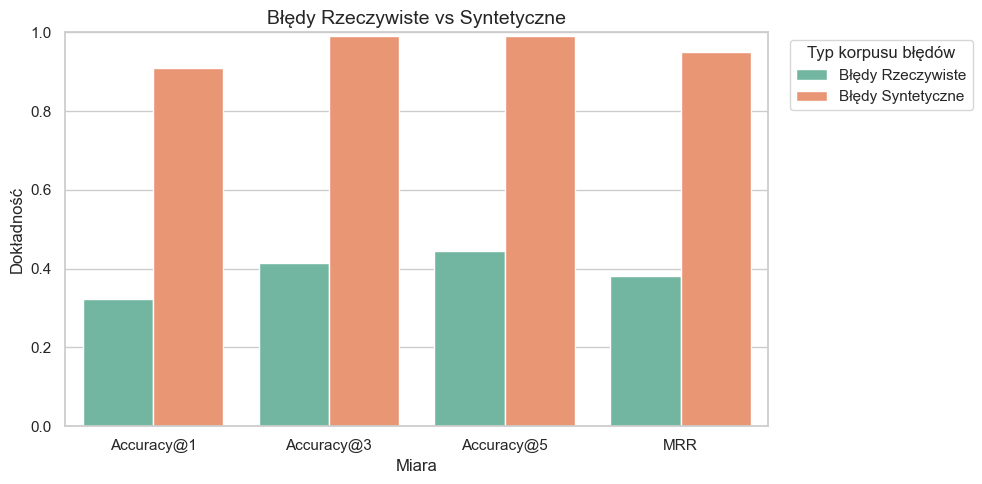

In [4]:
# ZESTAWIENIE WYNIKÓW DLA BŁĘDÓW SYNTETYCZNYCH I RZECZYWISTYCH

df_melted = df_wyniki.reset_index().melt(id_vars="index", var_name="Metryka", value_name="Wartość")

plt.figure(figsize=(10, 5))
sns.barplot(data=df_melted, x="Metryka", y="Wartość", hue="index", palette="Set2")
plt.title("Błędy Rzeczywiste vs Syntetyczne", fontsize=14)
plt.ylim(0, 1.0)
plt.ylabel("Dokładność")
plt.xlabel("Miara")
plt.legend(title="Typ korpusu błędów", loc='best', bbox_to_anchor = (1.02,1))
plt.tight_layout()
plt.show()

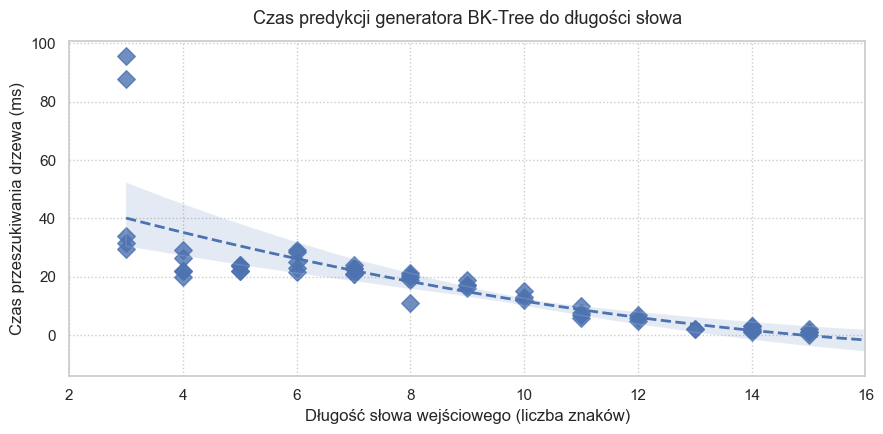

In [5]:
# WYKRES CZASU PREDYKCJI DO DŁUGOŚCI SŁOWA

dlugosci_slow = []
czasy_wykonania = []

# Próba słów o zróżnicowanej długości (od 3 do 15 znaków)
test_vocabulary = [
    # 3 znaki
    "kot", "dom", "las", "syn", "sok",
    # 4 znaki
    "ryba", "zima", "okno", "czas", "pies",
    # 5 znaków
    "mleko", "słowo", "wiatr", "trawa", "ekran",
    # 6 znaków
    "myszka", "gitara", "szkoła", "drzewo", "bramka",
    # 7 znaków
    "telefon", "student", "problem", "zegarek", "fabryka",
    # 8 znaków
    "samochód", "marakuja", "słyszący", "lotnisko", "komputer",
    # 9 znaków
    "lekarstwo", "prezydent", "szybowiec", "czekolada", "kaloryfer"
    # 10 znaków
    "nauczyciel", "biblioteka", "środowisko", "mieszkanie", "klawiatura"
    # 11 znaków
    "uniwersytet", "gastronomia", "kajakarstwo", "temperatura", "restauracja",
    # 12 znaków
    "wyszukiwanie", "skrzyżowanie", "podobieństwo", "częstotliwość", "architektura"
    # 13 znaków
    "samokrytyczny", "bezpieczeństwo", "społeczeństwo", "przedsiębiorca", "wykształcenie"
    # 14 znaków
    "charakterystyka", "samodyscyplina", "stowarzyszenie", "maksymalizacja", "obezwładnienie"
    # 15 znaków
    "odpowiedzialnie", "telekomunikacja", "nadopiekuńczość", "paralotniarstwo", "bezkompromisowy"
]

for slowo in test_vocabulary:

    if isinstance(slowo, bytes):
        slowo = slowo.decode('utf-8')
    start = time.time()
    # Sprawdzanie surowego czas odpowiedzi generatora BK
    _ = ranker.bk_tree.search(slowo, max_dist=2)
    end = time.time()
    
    dlugosci_slow.append(len(slowo))
    czasy_wykonania.append((end - start) * 1000) # Konwersja na milisekundy

# Wykres trendu

plt.figure(figsize=(9, 4.5))
sns.regplot(x=dlugosci_slow, y=czasy_wykonania, order=2, color="b", marker="D",
            scatter_kws={"s": 80}, line_kws={"linewidth": 2, "linestyle": "--"})
plt.xlim(2, 16)
plt.title("Czas predykcji generatora BK-Tree do długości słowa", fontsize=13, pad=12)
plt.xlabel("Długość słowa wejściowego (liczba znaków)")
plt.ylabel("Czas przeszukiwania drzewa (ms)")
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

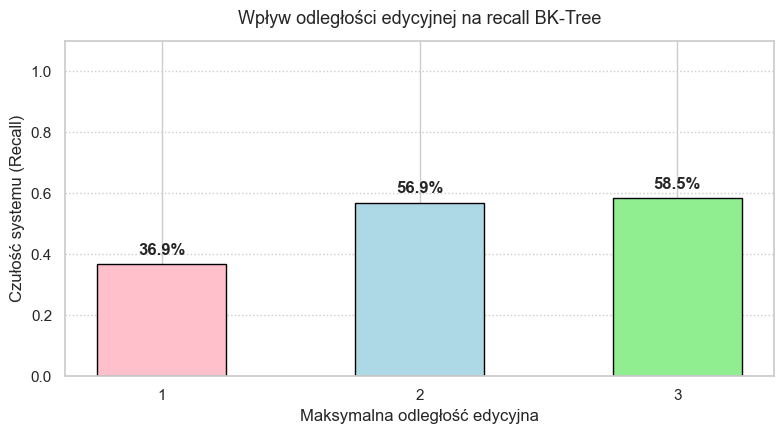

In [6]:
# RECALL GENERATORA KANDYDATÓW VS TOLEROWANA ODLEGŁOŚĆ EDYCYJNA

progi_dystansu = [1, 2, 3]
wyniki_recall = []

# Dla jakiej odległości poprawne słowo w ogóle znajduje się w wynikach
for dist in progi_dystansu:
    znalezione = 0
    for err_w, corr_w in lista_bledow:
        kandydaci = [c for c, _ in ranker.bk_tree.search(err_w, max_dist=dist)]
        if corr_w in kandydaci:
            znalezione += 1
    wyniki_recall.append(znalezione / len(lista_bledow))

# Rysowanie wykresu Recall
plt.figure(figsize=(8, 4.5))
bars = plt.bar(progi_dystansu, wyniki_recall, color=["pink", "lightblue", "lightgreen"], width=0.5, edgecolor='black')
plt.title("Wpływ odległości edycyjnej na recall BK-Tree", fontsize=13, pad=12)
plt.xlabel("Maksymalna odległość edycyjna")
plt.ylabel("Czułość systemu (Recall)")
plt.xticks(progi_dystansu)
plt.ylim(0, 1.1)

# Dodanie wartości procentowych
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f"{yval*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle=":")
plt.tight_layout()
plt.show()